In [6]:
# !pip install qiskit-ibm-runtime

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [16]:
circuit = QuantumCircuit(2, 2)

circuit.h(0)
circuit.cx(0, 1)

circuit.measure([0, 1], [0, 1])

In [17]:
circuit.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

In [18]:
circuit.parameters

ParameterView([])

In [23]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='open-instance',
    token='GxJLCChZSqPxJu02Qleqk3ayzZQy46Av8IsrHWYRyzaq'
)
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

qiskit_runtime_service._discover_account:WARNING:2026-05-18 22:45:55,451: Loading account with the given token. A saved account will not be used.


<IBMBackend('ibm_kingston')>


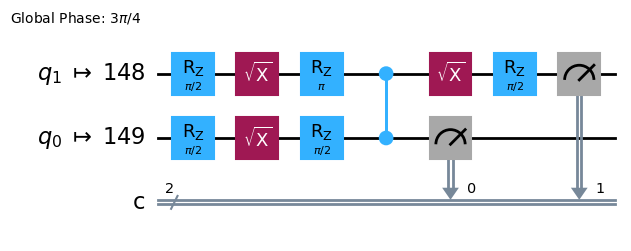

In [24]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

# using Estimator

In [29]:
observables_labels = ["ZZ"]
observables = [SparsePauliOp(label) for label in observables_labels]

isa_observables = [obsv.apply_layout(candidate_circuit.layout) for obsv in observables]

In [30]:
estimator = Estimator(mode=backend)

In [31]:
job = estimator.run([(candidate_circuit, isa_observables)])

In [32]:
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d85kl2g0bvlc73d5ns20
>>> Job Status: DONE


In [33]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': True, 'zne_mitigation': False, 'pec_mitigation': False}, 'version': 2})
  > Expectation value: [1.00112402]
  > Metadata: {'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32}


In [34]:
job_result = job.result()
pub_result = job.result()[0]

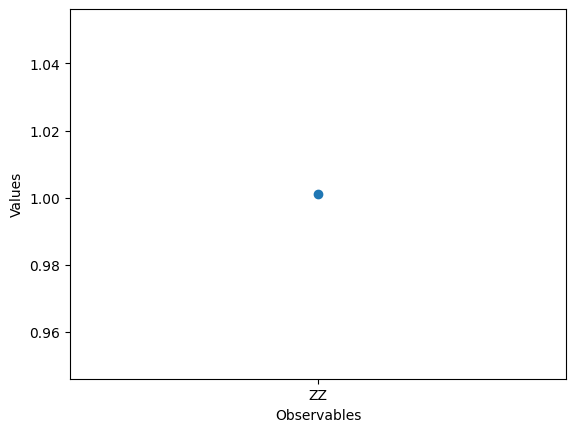

In [35]:
values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

# using Sampler

In [36]:
sampler_real = Sampler(mode=backend)

In [37]:
job_counts_sampler = sampler_real.run([(candidate_circuit)], shots=1024)

In [39]:
print(f">>> Job ID: {job_counts_sampler.job_id()}")
print(f">>> Job Status: {job_counts_sampler.status()}")

>>> Job ID: d85kmd7tjchs73bred50
>>> Job Status: DONE


In [40]:
result_sampler = job_counts_sampler.result()
result_sampler

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-05-18 17:24:07', stop='2026-05-18 17:24:08', size=1024>)])}, 'version': 2})

In [41]:
counts_real = result_sampler[0].data.c.get_counts()

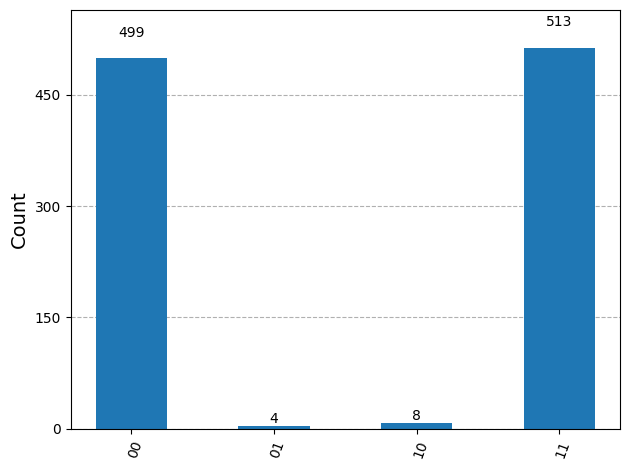

In [44]:
plot_histogram(counts_real)